In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:
df = pd.read_csv("tkcm/results_shifted.csv")

print(df.head())

   mode  k   l  d  alpha  index      real      pred     error
0  mean  3  12  3    0.5   3447  0.970043  0.973119  0.003075
1  mean  3  12  3    0.5   3448  0.971529  0.974253  0.002724
2  mean  3  12  3    0.5   3449  0.973192  0.974467  0.001275
3  mean  3  12  3    0.5   3450  0.974923  0.971597  0.003327
4  mean  3  12  3    0.5   3451  0.976593  0.970614  0.005979


In [85]:
df.groupby("mode")["error"].mean()

mode
mean            0.040361
weighted_exp    0.040302
weighted_inv    0.039166
Name: error, dtype: float64

In [86]:
df.groupby("mode")["error"].describe()

,count,mean,std,min,25%,50%,75%,max
mode,,,,,,,,
mean,17260.0,0.040361,0.055970,0.000001,0.005191,0.013699,0.052503,0.320795
weighted_exp,17260.0,0.040302,0.055979,0.000001,0.005192,0.013671,0.052195,0.320598
weighted_inv,17260.0,0.039166,0.056283,0.000001,0.004804,0.012651,0.048238,0.318864


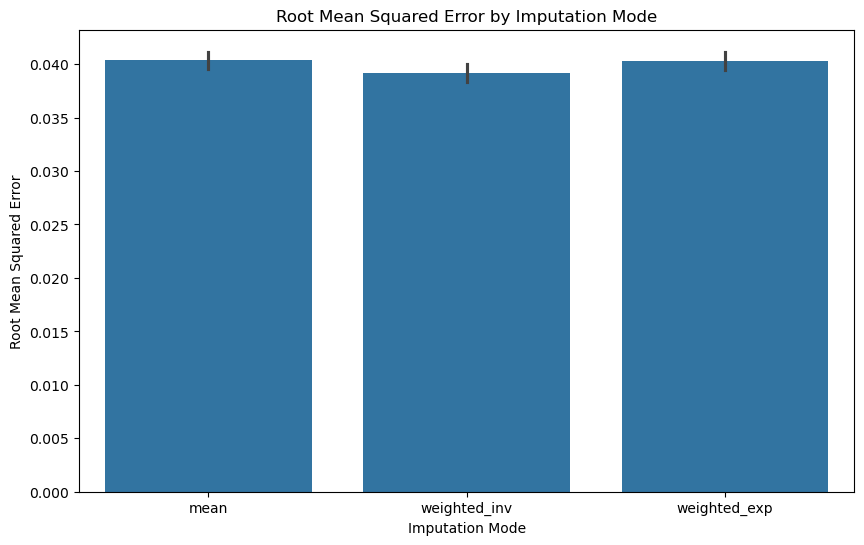

In [87]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="mode", y="error", data=df)
plt.title("Root Mean Squared Error by Imputation Mode")
plt.ylabel("Root Mean Squared Error")
plt.xlabel("Imputation Mode")
plt.savefig('figures_shifted/imputation_mode_rmse.png')
plt.show()


In [88]:
# rank the grouped results by error
grouped_df = df.groupby(["mode", "k", "l"])["error"].mean().reset_index()
sorted_df = grouped_df.sort_values("error")
sorted_df.head()

,mode,k,l,error
59,weighted_inv,9,96,0.034450
19,mean,9,96,0.034486
39,weighted_exp,9,96,0.034650
54,weighted_inv,7,96,0.035166
14,mean,7,96,0.035309


In [101]:
# best parameter combination per mode
best_params = grouped_df.loc[
    grouped_df.groupby("mode")["error"].idxmin()
]
print("Shifted chlorine dataset results:")
print("Best parameter combinations per mode:")
print(best_params)
worst_params = grouped_df.loc[
    grouped_df.groupby("mode")["error"].idxmax()
]
print("Worst parameter combinations per mode:")
print(worst_params)

Shifted chlorine dataset results:
Best parameter combinations per mode:
            mode  k   l     error
19          mean  9  96  0.034486
39  weighted_exp  9  96  0.034650
59  weighted_inv  9  96  0.034450
Worst parameter combinations per mode:
            mode  k   l     error
2           mean  3  48  0.047302
22  weighted_exp  3  48  0.047125
41  weighted_inv  3  24  0.045209


In [91]:
best_params_dict = {}

for mode in best_params["mode"].unique():
    row = best_params[best_params["mode"] == mode].iloc[0]
    k = row["k"]
    l = row["l"]
    mode = row["mode"]
    print(f"Best parameters for mode {mode}: k={row['k']}, l={row['l']} with error={row['error']}")
    # store the best parameters for each mode in a dictionary
    best_params_dict[mode] = {"k": k, "l": l}

worst_params_dict = {}
for mode in worst_params["mode"].unique():
    row = worst_params[worst_params["mode"] == mode].iloc[0]
    k = row["k"]
    l = row["l"]
    mode = row["mode"]
    print(f"Worst parameters for mode {mode}: k={row['k']}, l={row['l']} with error={row['error']}")
    # store the worst parameters for each mode in a dictionary
    
    worst_params_dict[mode] = {"k": k, "l": l}

Best parameters for mode mean: k=9, l=96 with error=0.034486479721900345
Best parameters for mode weighted_exp: k=9, l=96 with error=0.03465023290845887
Best parameters for mode weighted_inv: k=9, l=96 with error=0.034450352259559676
Worst parameters for mode mean: k=3, l=48 with error=0.047302134414831984
Worst parameters for mode weighted_exp: k=3, l=48 with error=0.047125123986095016
Worst parameters for mode weighted_inv: k=3, l=24 with error=0.04520923870220163


In [92]:
best_params_dict

{'mean': {'k': np.int64(9), 'l': np.int64(96)},
 'weighted_exp': {'k': np.int64(9), 'l': np.int64(96)},
 'weighted_inv': {'k': np.int64(9), 'l': np.int64(96)}}

In [93]:
worst_params_dict

{'mean': {'k': np.int64(3), 'l': np.int64(48)},
 'weighted_exp': {'k': np.int64(3), 'l': np.int64(48)},
 'weighted_inv': {'k': np.int64(3), 'l': np.int64(24)}}

In [94]:
best_runs = df.merge(best_params, on=["mode", "k", "l"], how="inner")
worst_runs = df.merge(worst_params, on=["mode", "k", "l"], how="inner")


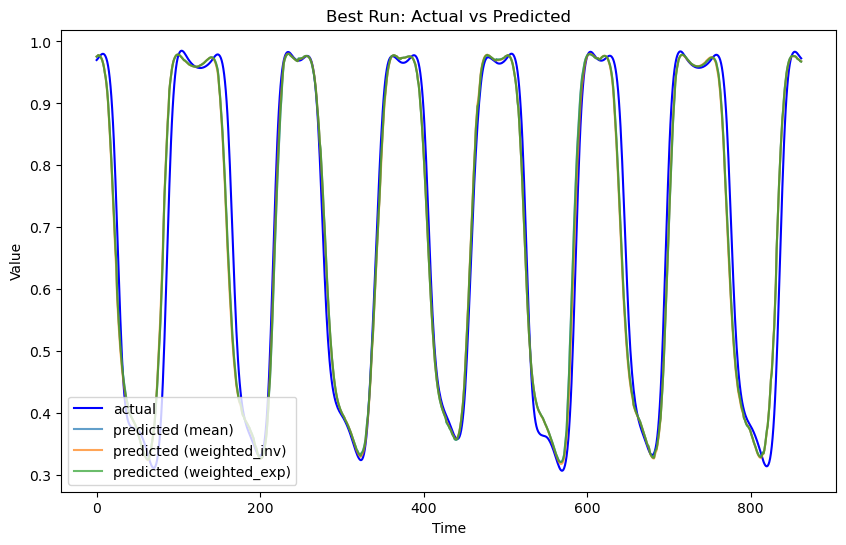

In [95]:
real_ts = best_runs[best_runs["mode"] == "mean"]["real"].to_numpy()
plt.figure(figsize=(10,6))
plt.plot(real_ts, label="actual", color="blue")
for mode in best_runs["mode"].unique():
    predicted_ts = best_runs[best_runs["mode"] == mode]["pred"].to_numpy()
    plt.plot(predicted_ts, label=f"predicted ({mode})", alpha=0.7)

plt.title("Best Run: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='lower left')
plt.savefig('figures_shifted/best_run_predictions.png')
plt.show()


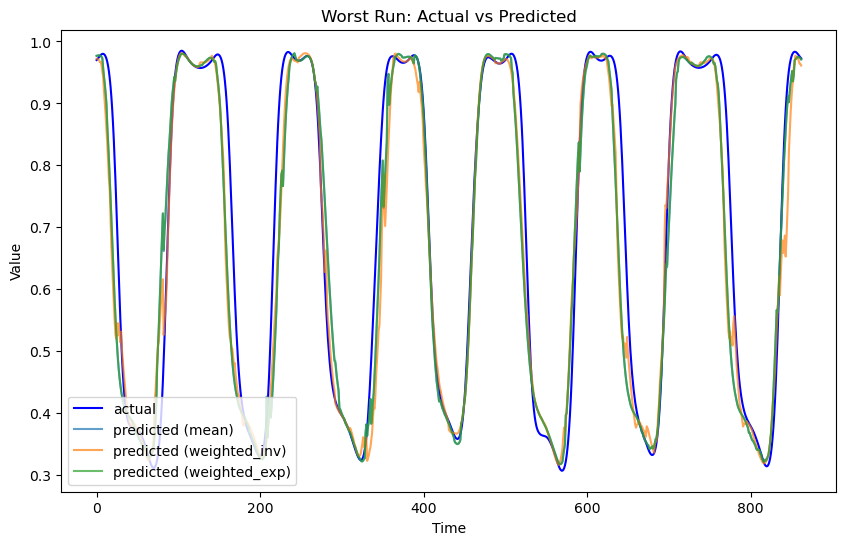

In [96]:
plt.figure(figsize=(10,6))
plt.plot(real_ts, label="actual", color="blue")
for mode in worst_runs["mode"].unique():
    predicted_ts = worst_runs[worst_runs["mode"] == mode]["pred"].to_numpy()
    plt.plot(predicted_ts, label=f"predicted ({mode})", alpha=0.7)

plt.title("Worst Run: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='lower left')
plt.savefig('figures_shifted/worst_run_predictions.png')
plt.show()


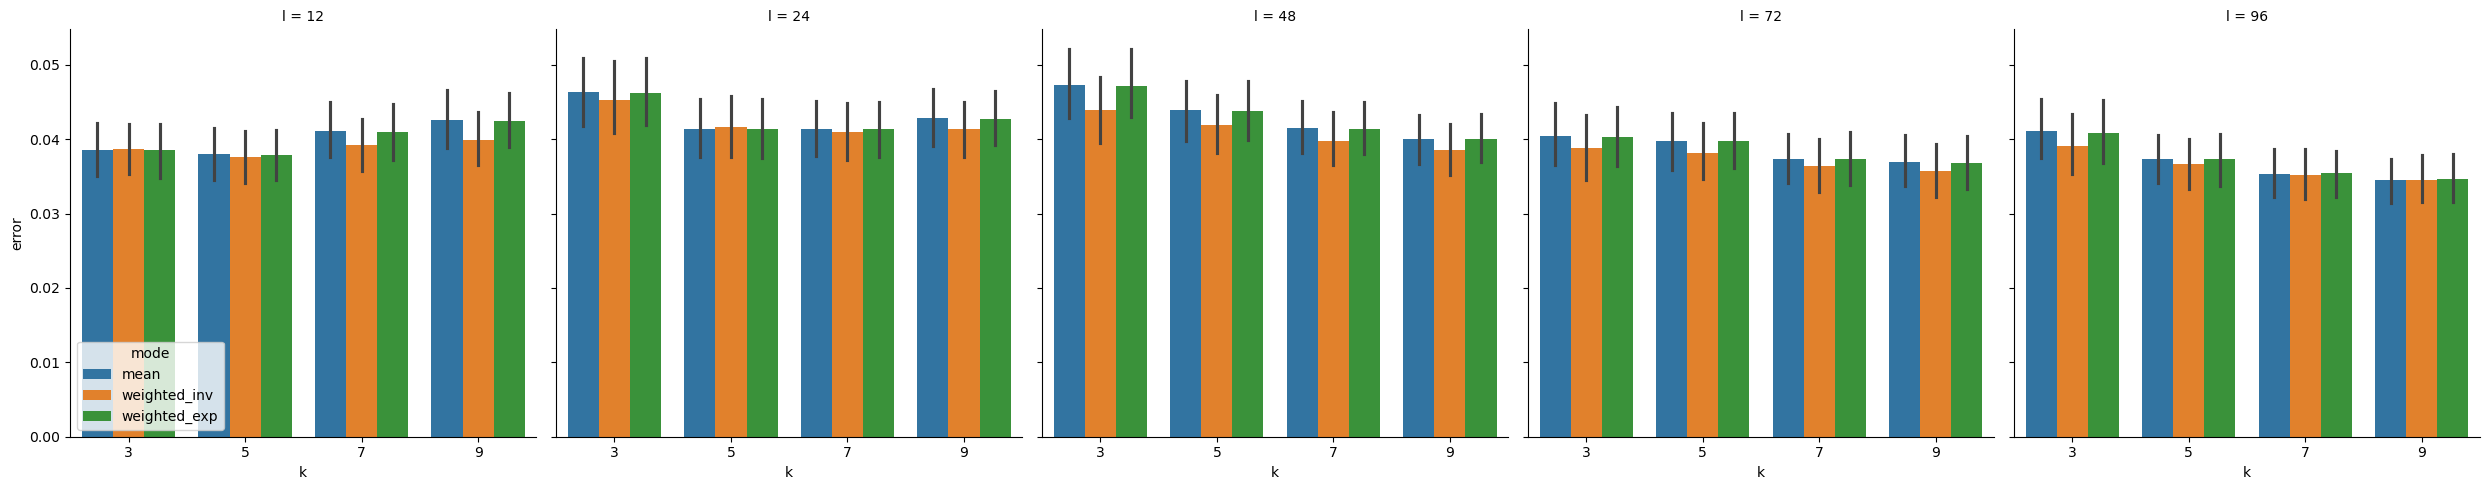

In [97]:
# plot the error for each mode as a function of k and l
sns.catplot(
    data=df,
    x="k",
    y="error",
    hue="mode",
    col="l",
    kind="bar",
    legend_out=False,
)
plt.savefig('figures_shifted/error_by_k_l_mode.png')
plt.show()


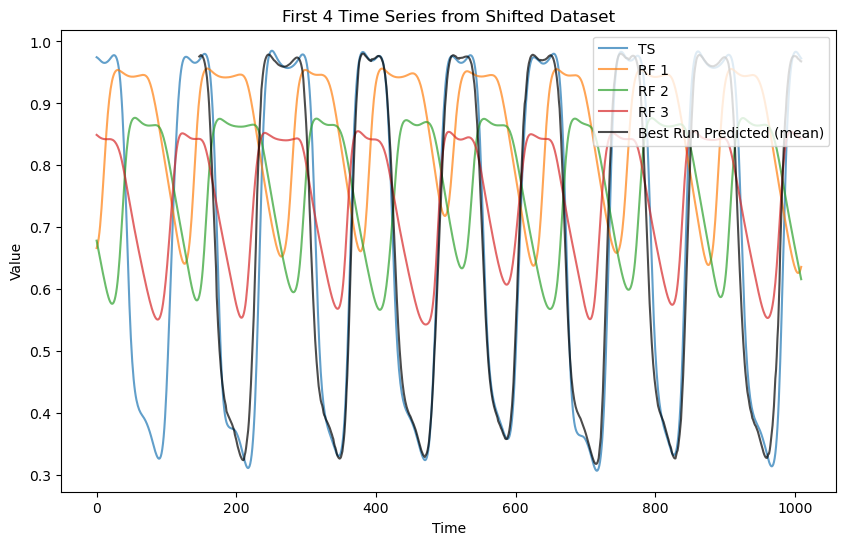

In [98]:
# get the first 4 time series from cl2fullLarge_shifted.dat
data = np.loadtxt("tkcm/cl2fullLarge_shifted.dat")
first_4_ts = data[:, :4]

best_predicted_ts = best_runs[best_runs["mode"] == "weighted_inv"]["pred"].to_numpy()
start = 3300
predicted_padded = np.full_like(first_4_ts[start:, 0], np.nan)
predicted_padded[len(predicted_padded)-len(best_predicted_ts):] = best_predicted_ts
# plot the first 4 time series 
plt.figure(figsize=(10,6))
for i in range(4):
    plt.plot(first_4_ts[start:, i], label=f"TS" if i == 0 else f"RF {i}", alpha=0.7)
# plot the predicted values for the best run on top of the actual values
plt.plot(predicted_padded, label="Best Run Predicted (mean)", color="black", alpha=0.7)
plt.title("First 4 Time Series from Shifted Dataset")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='upper right')
plt.savefig('figures_shifted/first_4_time_series.png')
plt.show()

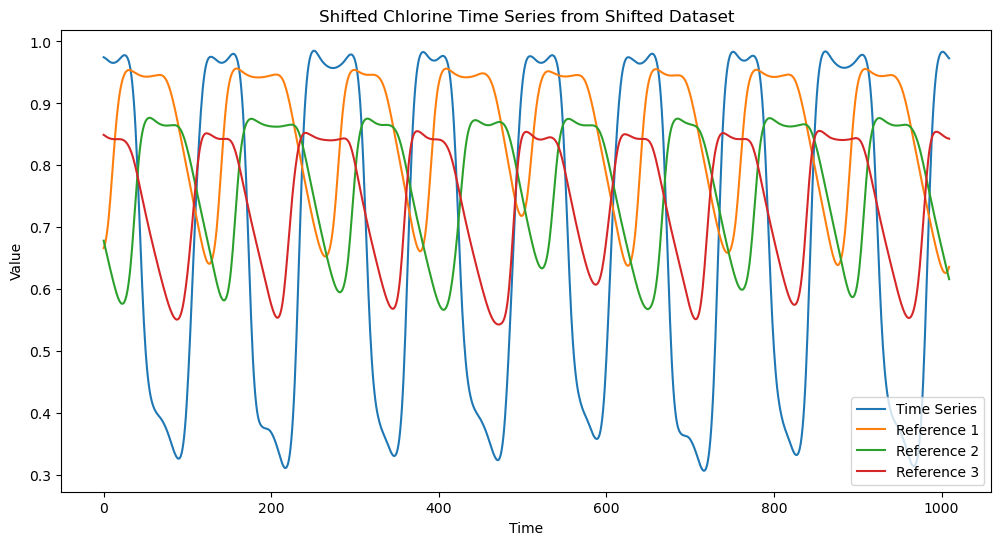

In [99]:
# plot the first 4 time series 
plt.figure(figsize=(12,6))
for i in range(4):
    plt.plot(first_4_ts[start:, i], label=f"Time Series" if i == 0 else f"Reference {i}")
plt.title("Shifted Chlorine Time Series from Shifted Dataset")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='lower right')
plt.savefig('figures_shifted/first_4_time_series.png')
plt.show()